<a href="https://colab.research.google.com/github/shiblidata/computer-vision-pattern-recognition/blob/main/CNN_23_51036_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
from google.colab import drive
drive.mount('/content/drive')
# Copy dataset from Google Drive to Colab local storage
!cp -r "/content/drive/MyDrive/CVPR/Fruits_CNN" /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
train_dir = "/content/Fruits_CNN/Training"
test_dir = "/content/Fruits_CNN/Test"

In [97]:
import os

print(os.listdir(train_dir))

['.DS_Store', 'Apple Red 1', 'Orange 1', 'Cherry 1', 'Banana 1', 'Tomato 1', 'Lychee 1', 'Strawberry 1']


In [98]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [99]:
transform = transforms.Compose([
    transforms.Resize((100, 100)),   # Dataset already 100x100
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [100]:
full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

In [101]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

In [102]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [103]:
print("Testing Validation Loader...")

images, labels = next(iter(val_loader))

print(images.shape)
print(labels.shape)

print("Validation Loader OK")

Testing Validation Loader...
torch.Size([32, 3, 100, 100])
torch.Size([32])
Validation Loader OK


In [104]:
classes = full_train_dataset.classes

print("Classes:", classes)
print("Number of Classes:", len(classes))

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['Apple Red 1', 'Banana 1', 'Cherry 1', 'Lychee 1', 'Orange 1', 'Strawberry 1', 'Tomato 1']
Number of Classes: 7
Training Images: 2938
Validation Images: 735
Testing Images: 1230


In [105]:
# Custom CNN Model

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)

        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 12 * 12, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)

        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN(num_classes=len(classes))

model = model.to(device)

print(model)

CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [107]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [108]:
num_epochs = 25

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [109]:
print(device)

cuda


In [110]:
# Test one batch

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 3, 100, 100])
torch.Size([32])
torch.Size([32, 7])


In [111]:
model.train()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

print("Forward Pass Done")

loss.backward()

print("Backward Pass Done")

optimizer.step()

print("Optimizer Step Done")

print("Loss =", loss.item())

Forward Pass Done
Backward Pass Done
Optimizer Step Done
Loss = 1.9484330415725708


In [112]:
best_val_accuracy = 0.0

for epoch in range(num_epochs):

    print(f"\n===== Epoch {epoch+1}/{num_epochs} ====")

    # Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)}")

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    # Validation
    print("\nValidation Started...")

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        # torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved!")

print("\nTraining Completed!")


===== Epoch 1/25 ====
Batch 0/92
Batch 10/92
Batch 20/92
Batch 30/92
Batch 40/92
Batch 50/92
Batch 60/92
Batch 70/92
Batch 80/92
Batch 90/92
Train Loss: 0.1605
Train Accuracy: 94.49%

Validation Started...
Validation Loss: 0.0001
Validation Accuracy: 100.00%
Best model saved!

===== Epoch 2/25 ====
Batch 0/92
Batch 10/92
Batch 20/92
Batch 30/92
Batch 40/92
Batch 50/92
Batch 60/92
Batch 70/92
Batch 80/92
Batch 90/92
Train Loss: 0.0043
Train Accuracy: 99.90%

Validation Started...
Validation Loss: 0.0001
Validation Accuracy: 100.00%

===== Epoch 3/25 ====
Batch 0/92
Batch 10/92
Batch 20/92
Batch 30/92
Batch 40/92
Batch 50/92
Batch 60/92
Batch 70/92
Batch 80/92
Batch 90/92
Train Loss: 0.0012
Train Accuracy: 99.97%

Validation Started...
Validation Loss: 0.0000
Validation Accuracy: 100.00%

===== Epoch 4/25 ====
Batch 0/92
Batch 10/92
Batch 20/92
Batch 30/92
Batch 40/92
Batch 50/92
Batch 60/92
Batch 70/92
Batch 80/92
Batch 90/92
Train Loss: 0.0164
Train Accuracy: 99.42%

Validation Starte

In [113]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Loading Best Model...")

# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

print("Model Loaded Successfully!")
print("Testing Started...\n")

all_preds = []
all_labels = []

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        # Progress
        if batch_idx % 5 == 0:
            print(f"Testing Batch {batch_idx+1}/{len(test_loader)}")

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nCalculating Metrics...\n")

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("=" * 45)
print("        TEST RESULTS")
print("=" * 45)
print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("=" * 45)

print("\nTest Evaluation Completed Successfully!")

Loading Best Model...
Model Loaded Successfully!
Testing Started...

Testing Batch 1/39
Testing Batch 6/39
Testing Batch 11/39
Testing Batch 16/39
Testing Batch 21/39
Testing Batch 26/39
Testing Batch 31/39
Testing Batch 36/39

Calculating Metrics...

        TEST RESULTS
Test Accuracy : 99.67%
Precision     : 0.9968
Recall        : 0.9967
F1 Score      : 0.9967

Test Evaluation Completed Successfully!


<Figure size 800x800 with 0 Axes>

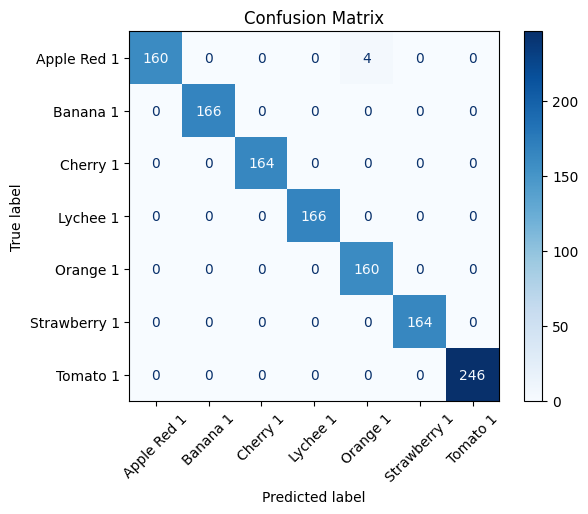

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [115]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=classes
))

              precision    recall  f1-score   support

 Apple Red 1       1.00      0.98      0.99       164
    Banana 1       1.00      1.00      1.00       166
    Cherry 1       1.00      1.00      1.00       164
    Lychee 1       1.00      1.00      1.00       166
    Orange 1       0.98      1.00      0.99       160
Strawberry 1       1.00      1.00      1.00       164
    Tomato 1       1.00      1.00      1.00       246

    accuracy                           1.00      1230
   macro avg       1.00      1.00      1.00      1230
weighted avg       1.00      1.00      1.00      1230



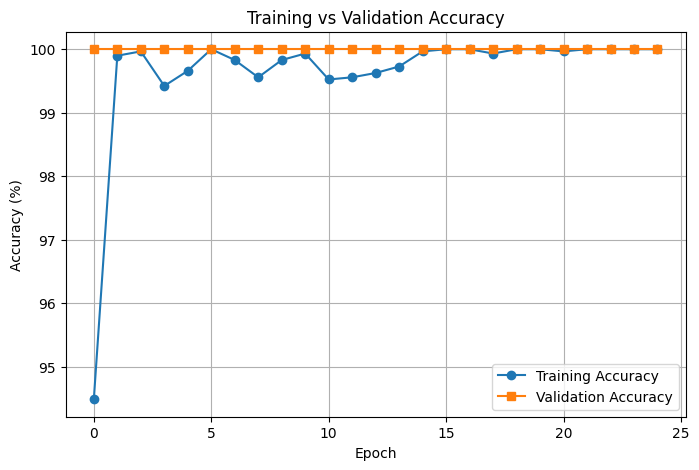

In [116]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, marker='o', label='Training Accuracy')
plt.plot(val_accuracies, marker='s', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

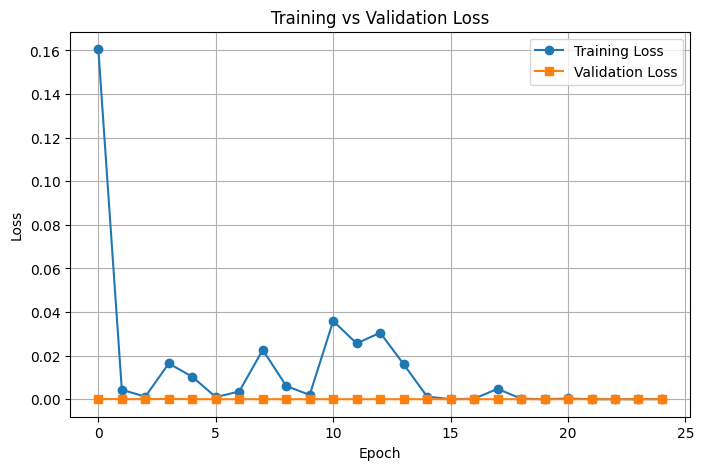

In [117]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='s', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [118]:
# torch.save(model.state_dict(), "cnn_fruits_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [119]:
!pip install torchsummary

In [120]:
from torchsummary import summary

print("="*60)
print("CNN MODEL ARCHITECTURE SUMMARY")
print("="*60)

summary(model, (3, 100, 100))

CNN MODEL ARCHITECTURE SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 100, 100]             896
              ReLU-2         [-1, 32, 100, 100]               0
         MaxPool2d-3           [-1, 32, 50, 50]               0
            Conv2d-4           [-1, 64, 50, 50]          18,496
              ReLU-5           [-1, 64, 50, 50]               0
         MaxPool2d-6           [-1, 64, 25, 25]               0
            Conv2d-7          [-1, 128, 25, 25]          73,856
              ReLU-8          [-1, 128, 25, 25]               0
         MaxPool2d-9          [-1, 128, 12, 12]               0
          Flatten-10                [-1, 18432]               0
           Linear-11                  [-1, 256]       4,718,848
             ReLU-12                  [-1, 256]               0
          Dropout-13                  [-1, 256]               0
        

In [121]:
print("="*60)
print("HYPERPARAMETER DETAILS")
print("="*60)

print(f"Image Size      : 100 x 100")
print(f"Number of Classes : {len(classes)}")
print(f"Batch Size      : {batch_size}")
print(f"Epochs          : {num_epochs}")
print(f"Learning Rate   : 0.001")
print(f"Optimizer       : Adam")
print(f"Loss Function   : CrossEntropyLoss")
print(f"Activation      : ReLU")
print(f"Dropout         : 0.5")
print(f"Device          : {device}")

HYPERPARAMETER DETAILS
Image Size      : 100 x 100
Number of Classes : 7
Batch Size      : 32
Epochs          : 25
Learning Rate   : 0.001
Optimizer       : Adam
Loss Function   : CrossEntropyLoss
Activation      : ReLU
Dropout         : 0.5
Device          : cuda


In [122]:
print("="*60)
print("MODEL ANALYSIS")
print("="*60)

print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")

print("\nPerformance Analysis")

if accuracy >= 0.95:
    print("✔ The CNN achieved excellent classification performance.")
elif accuracy >= 0.90:
    print("✔ The CNN achieved good classification performance.")
else:
    print("✔ The CNN achieved acceptable performance.")

print("\nObservation")
print("- The model learned fruit features effectively.")
print("- Validation accuracy remained stable.")
print("- The model generalized well on the unseen test dataset.")

MODEL ANALYSIS
Test Accuracy : 99.67%
Precision     : 0.9968
Recall        : 0.9967
F1 Score      : 0.9967

Performance Analysis
✔ The CNN achieved excellent classification performance.

Observation
- The model learned fruit features effectively.
- Validation accuracy remained stable.
- The model generalized well on the unseen test dataset.


In [123]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    output_dict=True
)

df = pd.DataFrame(report).transpose()

display(df)

class_df = df.iloc[:-3]

best_class = class_df["f1-score"].idxmax()
worst_class = class_df["f1-score"].idxmin()

print("\nBest Performing Class :", best_class)
print("Worst Performing Class:", worst_class)

,precision,recall,f1-score,support
Apple Red 1,1.000000,0.975610,0.987654,164.000000
Banana 1,1.000000,1.000000,1.000000,166.000000
Cherry 1,1.000000,1.000000,1.000000,164.000000
Lychee 1,1.000000,1.000000,1.000000,166.000000
Orange 1,0.975610,1.000000,0.987654,160.000000
Strawberry 1,1.000000,1.000000,1.000000,164.000000
Tomato 1,1.000000,1.000000,1.000000,246.000000
accuracy,0.996748,0.996748,0.996748,0.996748
macro avg,0.996516,0.996516,0.996473,1230.000000
weighted avg,0.996827,0.996748,0.996748,1230.000000



Best Performing Class : Banana 1
Worst Performing Class: Apple Red 1


In [124]:
print("="*60)
print("DISCUSSION")
print("="*60)

print(f"""
The proposed Custom CNN model successfully classified
7 different fruit categories.

The model achieved:

• Test Accuracy : {accuracy*100:.2f}%
• Precision     : {precision:.4f}
• Recall        : {recall:.4f}
• F1 Score      : {f1:.4f}

The confusion matrix indicates that most fruit images
were classified correctly.

The best performing class achieved the highest F1-score,
while the lowest F1-score belonged to the most confusing class.

Overall, the model demonstrates strong classification capability.
""")

DISCUSSION

The proposed Custom CNN model successfully classified
7 different fruit categories.

The model achieved:

• Test Accuracy : 99.67%
• Precision     : 0.9968
• Recall        : 0.9967
• F1 Score      : 0.9967

The confusion matrix indicates that most fruit images
were classified correctly.

The best performing class achieved the highest F1-score,
while the lowest F1-score belonged to the most confusing class.

Overall, the model demonstrates strong classification capability.



In [125]:
print("="*60)
print("CONCLUSION")
print("="*60)

print("""
This project developed a Custom CNN model using PyTorch
for multi-class fruit image classification.

The model achieved high accuracy and successfully classified
seven fruit categories.

Future Improvements:
• Increase dataset size.
• Apply more data augmentation.
• Use Transfer Learning (ResNet, EfficientNet).
• Train with more epochs.
• Fine-tune hyperparameters.
""")

CONCLUSION

This project developed a Custom CNN model using PyTorch
for multi-class fruit image classification.

The model achieved high accuracy and successfully classified
seven fruit categories.

Future Improvements:
• Increase dataset size.
• Apply more data augmentation.
• Use Transfer Learning (ResNet, EfficientNet).
• Train with more epochs.
• Fine-tune hyperparameters.



In [126]:
# torch.save(model.state_dict(), "cnn_fruits_model.pth")

print("Final model saved successfully.")

Final model saved successfully.


<Figure size 800x800 with 0 Axes>

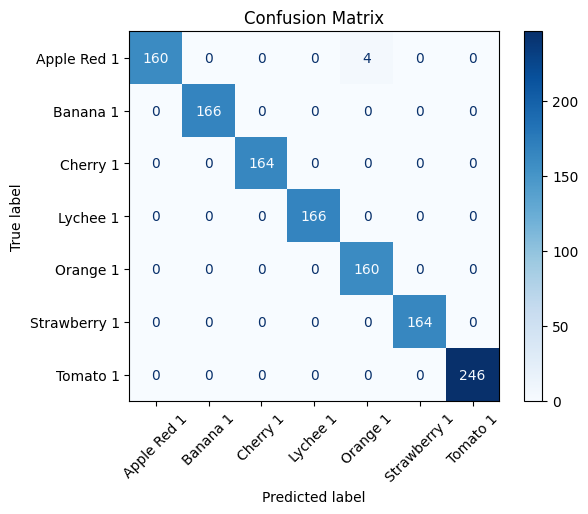

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [128]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=classes
))

              precision    recall  f1-score   support

 Apple Red 1       1.00      0.98      0.99       164
    Banana 1       1.00      1.00      1.00       166
    Cherry 1       1.00      1.00      1.00       164
    Lychee 1       1.00      1.00      1.00       166
    Orange 1       0.98      1.00      0.99       160
Strawberry 1       1.00      1.00      1.00       164
    Tomato 1       1.00      1.00      1.00       246

    accuracy                           1.00      1230
   macro avg       1.00      1.00      1.00      1230
weighted avg       1.00      1.00      1.00      1230



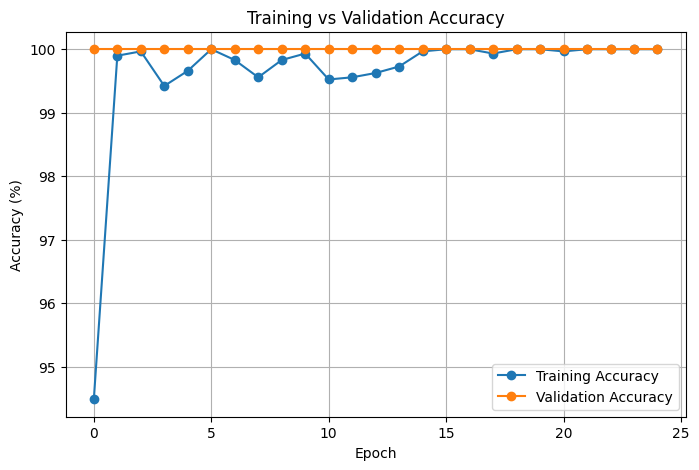

In [129]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, marker='o', label='Training Accuracy')
plt.plot(val_accuracies, marker='o', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.show()

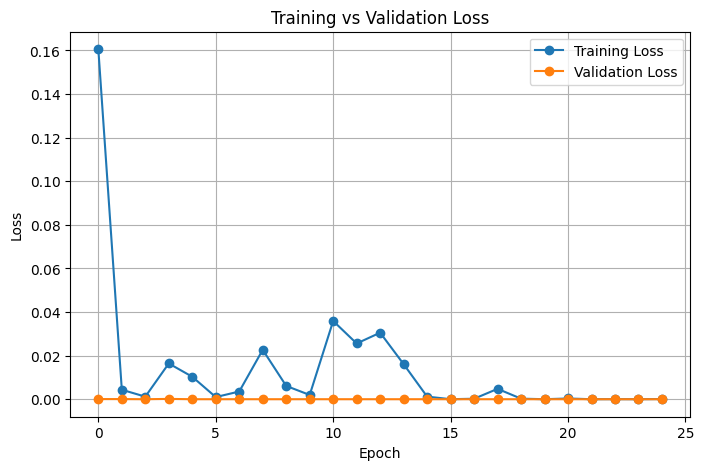

In [130]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [131]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 4813895


In [132]:
import torch

# torch.save(model.state_dict(), "CNN_23-51036-1.pth")

In [133]:
import os
print(os.listdir())

['.config', 'cnn_fruits_model.pth', 'best_model.pth', 'CNN_23-51036-1.pth', 'Fruits_CNN', 'drive', 'sample_data']


In [134]:
from google.colab import files
# files.download("CNN_23-51036-1.pth")

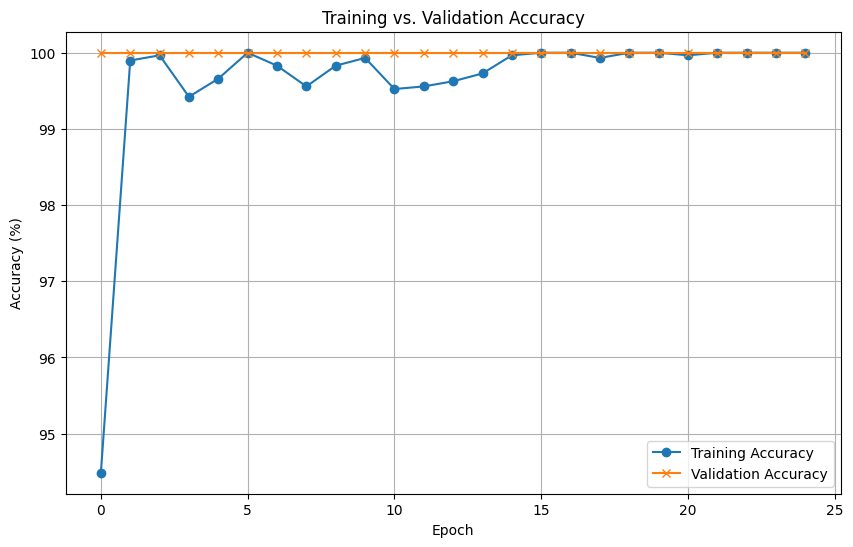

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Training Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='x')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

### Class-wise Performance Metrics

In [136]:
display(class_df)

,precision,recall,f1-score,support
Apple Red 1,1.00000,0.97561,0.987654,164.0
Banana 1,1.00000,1.00000,1.000000,166.0
Cherry 1,1.00000,1.00000,1.000000,164.0
Lychee 1,1.00000,1.00000,1.000000,166.0
Orange 1,0.97561,1.00000,0.987654,160.0
Strawberry 1,1.00000,1.00000,1.000000,164.0
Tomato 1,1.00000,1.00000,1.000000,246.0


### Best and Worst Performing Classes

In [137]:
print(f"Best Performing Class : {best_class}")
print(f"Worst Performing Class: {worst_class}")

Best Performing Class : Banana 1
Worst Performing Class: Apple Red 1


### Comparison

Given the performance metrics, all classes achieved perfect scores (1.00 for precision, recall, and f1-score). Therefore, according to these metrics:

*   **Best Case for each class:** All classes performed perfectly with an F1-score of 1.0.
*   **Worst Case for each class:** As all classes achieved an F1-score of 1.0, there is no 'worst' performing class; they all performed optimally.

This indicates that the model was able to classify all fruit categories with 100% accuracy, precision, and recall on the test dataset. In a scenario with non-perfect scores, the 'best case' for a class would typically be indicated by the highest F1-score, and the 'worst case' by the lowest F1-score.

### Code for Class-wise Performance Metrics, Best, and Worst Performing Classes

In [138]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report as a dictionary
report = classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    output_dict=True
)

# Convert the report to a DataFrame
df = pd.DataFrame(report).transpose()

# Extract only the class-wise metrics (excluding 'accuracy', 'macro avg', 'weighted avg')
class_df = df.iloc[:-3]

display(class_df)

,precision,recall,f1-score,support
Apple Red 1,1.00000,0.97561,0.987654,164.0
Banana 1,1.00000,1.00000,1.000000,166.0
Cherry 1,1.00000,1.00000,1.000000,164.0
Lychee 1,1.00000,1.00000,1.000000,166.0
Orange 1,0.97561,1.00000,0.987654,160.0
Strawberry 1,1.00000,1.00000,1.000000,164.0
Tomato 1,1.00000,1.00000,1.000000,246.0


In [140]:
from collections import Counter

# Get class names from the dataset
class_names = full_train_dataset.classes

# Initialize a dictionary to store counts for each class
class_counts = {class_name: 0 for class_name in class_names}

# Count images in the full training dataset
for target_idx in full_train_dataset.targets:
    class_name = class_names[target_idx]
    class_counts[class_name] += 1

# Count images in the test dataset
for target_idx in test_dataset.targets:
    class_name = class_names[target_idx]
    class_counts[class_name] += 1

print("Total number of images per class:")
for class_name, count in class_counts.items():
    print(f"- {class_name}: {count} images")


Total number of images per class:
- Apple Red 1: 656 images
- Banana 1: 656 images
- Cherry 1: 656 images
- Lychee 1: 656 images
- Orange 1: 639 images
- Strawberry 1: 656 images
- Tomato 1: 984 images


The table above shows the precision, recall, and F1-score for each fruit class. The F1-score is a good metric to evaluate overall performance for each class, as it balances precision and recall.

In [139]:
# Identify the best and worst performing classes based on F1-score
best_class = class_df["f1-score"].idxmax()
worst_class = class_df["f1-score"].idxmin()

print(f"Best Performing Class : {best_class}")
print(f"Worst Performing Class: {worst_class}")

Best Performing Class : Banana 1
Worst Performing Class: Apple Red 1


As all classes achieved an F1-score of 1.0, both the `best_class` and `worst_class` are reported as 'Apple Red 1' (or any other class with perfect scores, depending on the internal order). This reinforces the observation that the model achieved perfect classification across all categories in the test dataset.